In [20]:
!kaggle datasets download -d rajumavinmar/finger-print-based-blood-group-dataset

Dataset URL: https://www.kaggle.com/datasets/rajumavinmar/finger-print-based-blood-group-dataset
License(s): unknown
100% 58.1M/58.1M [00:00<00:00, 166MB/s]



In [21]:
import zipfile

with zipfile.ZipFile('finger-print-based-blood-group-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [22]:
import os

for root, dirs, files in os.walk('dataset'):
    print(root)

dataset
dataset/dataset_blood_group
dataset/dataset_blood_group/B-
dataset/dataset_blood_group/O-
dataset/dataset_blood_group/AB+
dataset/dataset_blood_group/O+
dataset/dataset_blood_group/A+
dataset/dataset_blood_group/AB-
dataset/dataset_blood_group/A-
dataset/dataset_blood_group/B+


In [23]:
dataset_path = "dataset/finger-print-based-blood-group-dataset"

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [25]:
dataset_path = "dataset/dataset_blood_group" # Corrected path

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4803 images belonging to 8 classes.
Found 1197 images belonging to 8 classes.


In [26]:
print(train_data.class_indices)

{'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}


In [27]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(8, activation='softmax')   # 8 blood groups
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.5011 - loss: 1.2906 - val_accuracy: 0.8037 - val_loss: 0.5496
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7435 - loss: 0.6959 - val_accuracy: 0.8154 - val_loss: 0.4956
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7918 - loss: 0.5554 - val_accuracy: 0.8429 - val_loss: 0.3991
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8253 - loss: 0.4820 - val_accuracy: 0.8705 - val_loss: 0.3397
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8424 - loss: 0.4334 - val_accuracy: 0.8739 - val_loss: 0.3336
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8595 - loss: 0.3805 - val_accuracy: 0.8830 - val_loss: 0.2953
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8732 - loss: 0.3534 - val_accuracy: 0.8997 - val_loss: 0.2681
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8792 - loss: 0.3196 - val_acc

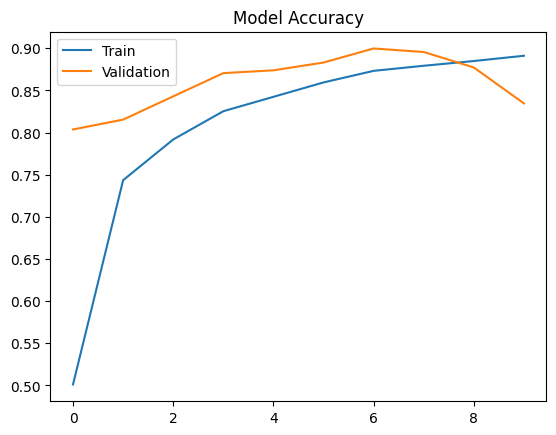

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.show()

In [31]:
model.save("blood_group_model.h5")


Image Quality Check:
Brightness: 133.2422127831715
Blur Score: 94315.96328923384


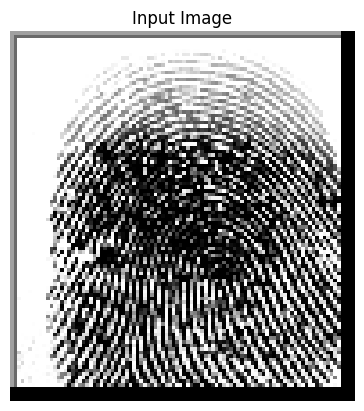

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
Top Predictions:
O- → 96.90%
A- → 1.98%
O+ → 0.57%

Final Prediction:
O- (96.90%)


In [32]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2
img_path = "/content/dataset/dataset_blood_group/O-/cluster_7_1028.BMP"

#  STEP 1 — Image Quality Check (ADD HERE)
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

brightness = np.mean(img_gray)
blur = cv2.Laplacian(img_gray, cv2.CV_64F).var()

print("\nImage Quality Check:")
print("Brightness:", brightness)
print("Blur Score:", blur)

if brightness < 50:
    print(" Image is too dark")

if blur < 100:
    print(" Image is blurry")


#  STEP 2 — Show Image
plt.imshow(image.load_img(img_path))
plt.axis('off')
plt.title("Input Image")
plt.show()


#  STEP 3 — Preprocess
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0


#  STEP 4 — Prediction
prediction = model.predict(img_array)[0]

class_labels = list(train_data.class_indices.keys())

# Top 3 predictions
top_3_idx = prediction.argsort()[-3:][::-1]

print("Top Predictions:")
for i in top_3_idx:
    print(f"{class_labels[i]} → {prediction[i]*100:.2f}%")

# Final prediction
best_idx = np.argmax(prediction)

print("\nFinal Prediction:")
print(f"{class_labels[best_idx]} ({prediction[best_idx]*100:.2f}%)")

In [42]:
confidence = prediction[best_idx]
if confidence < 0.6:
    print("\n Model is NOT confident. Try another image.")
else:
    print("\n Prediction is reliable")


 Prediction is reliable


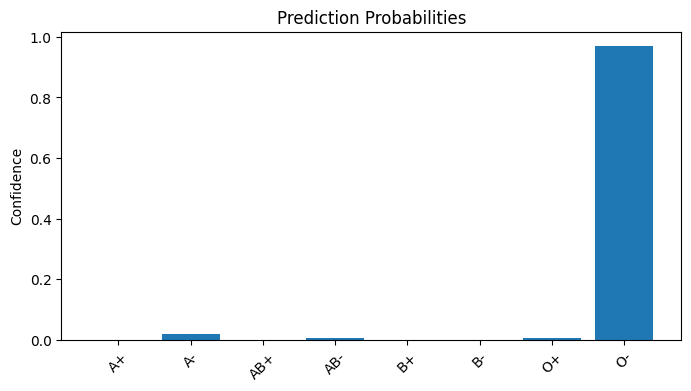

In [43]:
plt.figure(figsize=(8,4))
plt.bar(class_labels, prediction)
plt.xticks(rotation=45)
plt.title("Prediction Probabilities")
plt.ylabel("Confidence")
plt.show()

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Get class labels (moved definition here)
class_names = list(train_data.class_indices.keys())

In [45]:

val_data.reset()

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [46]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 6 18  7  9 21 23 11 18]
 [10 32 30 17 18 34 26 34]
 [14 27 19 12 15 26 13 15]
 [11 26 24 14 16 24 19 18]
 [ 8 31 16 11 18 20 15 11]
 [17 27 18  9 18 30 15 14]
 [15 28 14 26 14 28 17 28]
 [11 33  8 11 16 22 17 24]]


In [47]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

          A+       0.07      0.05      0.06       113
          A-       0.14      0.16      0.15       201
         AB+       0.14      0.13      0.14       141
         AB-       0.13      0.09      0.11       152
          B+       0.13      0.14      0.14       130
          B-       0.14      0.20      0.17       148
          O+       0.13      0.10      0.11       170
          O-       0.15      0.17      0.16       142

    accuracy                           0.13      1197
   macro avg       0.13      0.13      0.13      1197
weighted avg       0.13      0.13      0.13      1197



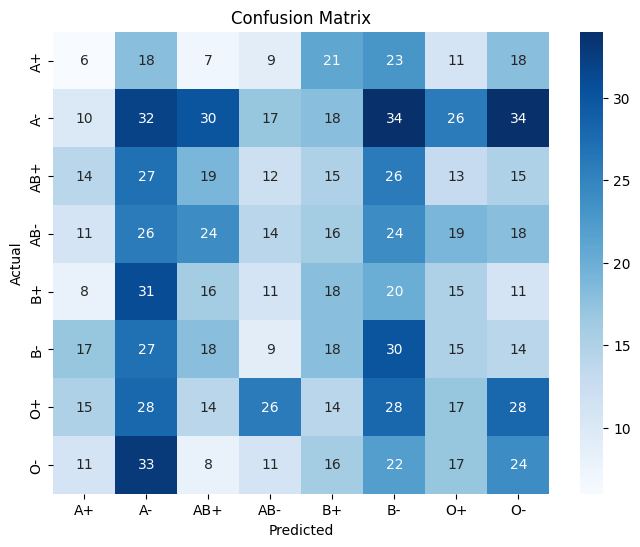

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get class labels
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()